# Week 1: Auditing algorithmic fairness with ACSIncome dataset

**Learning goals**

1. Separate a target label, a prediction, and a decision.
2. Validate performance and group fairness.
3. Connect independence, separation, sufficiency, and calibration to their assumptions.

**Project 1 (Week 1)**

1. Guided - Auditing algorithmic fairness with ACSIncome dataset
2. Transfer your learning and perform an audit on the Portuguese banking marketing campaign dataset


### Task 1: The task predicts whether annual income exceeds USD 50,000 using 2018 ACS data. `SEX` is the binary coding available in this survey extract. It is not a complete measurement of gender identity.

In [ ]:
pip -q install folktables fairlearn cleanlab scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 9.3 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/ADE-17/RAI_Project1_Fairness_Project.git

Cloning into 'RAI_Project1_Fairness_Project'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 49 (delta 28), reused 37 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 1.09 MiB | 8.80 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [ ]:
DATA_DIR = "/content/RAI_Project1_Fairness_Project/data"

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fairlearn

from IPython.display import display
from folktables import ACSDataSource, ACSIncome
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss,
    brier_score_loss, confusion_matrix, precision_score, recall_score,
)
from fairlearn.metrics import (
    MetricFrame, selection_rate, count, true_positive_rate,
    false_positive_rate, demographic_parity_difference,
    demographic_parity_ratio, equalized_odds_difference,
    equalized_odds_ratio,
)

RANDOM_STATE = 42
STATE = "CA"
MAX_SAMPLES = 50_000

## 1. Load and document the data

Before modelling, answer:

**- What population is represented?** 50 US states + Puerto Rico

**- What is the prediction target and who constructed it?** PINCP, total annual income per person, integer from 104 - 1.423.000

**-Which variables are measurements, proxies, or administratively defined categories?** Measurements: Work hours per week, place of birth, educational attainment, age, THIS DOESNT MATTER REALLY TOO ARBITRARY

- Have a look at dataset description for code names ('columns') and their description - https://fairlearn.org/main/user_guide/datasets/acs_income.html

In [ ]:
source = ACSDataSource(survey_year="2018", horizon="1-Year", survey="person")
acs = source.get_data(states=[STATE], download=True)
X_all, y_all, race_codes = ACSIncome.df_to_pandas(acs)

X_all = X_all.reset_index(drop=True)
y_reference = y_all.squeeze().astype(int).reset_index(drop=True)
race_codes = race_codes.squeeze().reset_index(drop=True)
sex_group = X_all["SEX"].map({1: "Male", 2: "Female"}).fillna("Unknown")
race_names = {
    1: "White", 2: "Black", 3: "American Indian", 4: "Alaska Native",
    5: "AIAN specified/other", 6: "Asian", 7: "Pacific Islander",
    8: "Other race", 9: "Two or more races",
}
race_group = race_codes.map(race_names).fillna("Unknown")

strata = y_reference.astype(str) + "_" + sex_group.astype(str)
if len(X_all) > MAX_SAMPLES:
    keep, _ = train_test_split(
        np.arange(len(X_all)), train_size=MAX_SAMPLES,
        random_state=RANDOM_STATE, stratify=strata,
    )
    X_all = X_all.iloc[keep].reset_index(drop=True)
    y_reference = y_reference.iloc[keep].reset_index(drop=True)
    sex_group = sex_group.iloc[keep].reset_index(drop=True)
    race_group = race_group.iloc[keep].reset_index(drop=True)

display(X_all.head())
display(pd.crosstab(sex_group, y_reference, normalize="index").rename(columns={0:"income<=50k",1:"income>50k"}))
print("Rows:", len(X_all), "Features:", X_all.shape[1])
print()
print("Sex distribution (counts):")
print(sex_group.value_counts())
print("\nSex distribution (ratio):")
print(sex_group.value_counts(normalize=True))

,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P
0,47.0,1.0,22.0,1.0,5740.0,6.0,1.0,40.0,2.0,1.0
1,44.0,1.0,19.0,1.0,440.0,6.0,0.0,45.0,1.0,1.0
2,41.0,4.0,16.0,1.0,4220.0,12.0,0.0,42.0,1.0,1.0
3,58.0,1.0,18.0,5.0,3605.0,6.0,0.0,40.0,1.0,2.0
4,36.0,1.0,19.0,1.0,1006.0,361.0,5.0,40.0,1.0,1.0


PINCP,income<=50k,income>50k
SEX,,
Female,0.650932,0.349068
Male,0.534432,0.465568


Rows: 50000 Features: 10

Sex distribution (counts):
SEX
Male      26400
Female    23600
Name: count, dtype: int64

Sex distribution (ratio):
SEX
Male      0.528
Female    0.472
Name: proportion, dtype: float64


- The data has 50.000 individuals and each with 10 features

- From the above table we get the percentage of male/female earning above or below/equal 50 k.

- We see 46 % of males make over 50 k a month and the rest of the males make below 50 K, while 34 % of female make above 50 K.

- In other words we see men are more likely overall to make above 50 compared to women

- We also see the men make up 52 % of all observations

### Label notation used throughout the course

| Symbol | Meaning | Use |
|---|---|---|
| $Y^{ref}$ | Best available reference outcome | Final validation and test audit |
| $Y^{obs}$ | Label available to us; in real-life | Training and realistic validation |
| $S=P(\hat Y=1)$ | Model score | Ranking and calibration |
| $\hat Y$ | Thresholded or postprocessed decision | Decision metrics |

In Week 1, $Y^{obs}=Y^{ref}$. Later weeks deliberately separate them. “Reference” is more accurate than “ground truth”: real labels can still be incomplete or contestable.

In [ ]:
idx = np.arange(len(X_all))
strata = y_reference.astype(str) + "_" + sex_group.astype(str)
train_idx, temp_idx = train_test_split(idx, test_size=.40, random_state=RANDOM_STATE, stratify=strata)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=.50, random_state=RANDOM_STATE,
    stratify=strata.iloc[temp_idx],
)

def take(x, ids):
    return x.iloc[ids].reset_index(drop=True)

X_train, X_val, X_test = [take(X_all, z) for z in (train_idx, val_idx, test_idx)]
y_train, y_val, y_test = [take(y_reference, z) for z in (train_idx, val_idx, test_idx)]
A_train, A_val, A_test = [take(sex_group, z) for z in (train_idx, val_idx, test_idx)]
R_train, R_val, R_test = [take(race_group, z) for z in (train_idx, val_idx, test_idx)]

display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(X_train), len(X_val), len(X_test)],
    "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    "female_fraction": [(A_train=="Female").mean(), (A_val=="Female").mean(), (A_test=="Female").mean()],
}))

,split,n,positive_rate,female_fraction
0,train,30000,0.4106,0.472
1,validation,10000,0.4105,0.472
2,test,10000,0.4106,0.472


- We see the 3 datasets: train, validation , test

- We see the train set is 3 times higher in observations compared to validation and test. Test and validation have the same number of observations

- We see the positive rate in all 3 datasets are the same I assume this is ratio of all observations making above 50 k ?

- We see the female fraction is the same across all three dataseets of ~47 %

## 2. Fit a transparent baseline

We retain `SEX` and `RAC1P` for the first model. (Later, compare a model that excludes them.)

**Removing a sensitive attribute does not remove proxies and is not itself a fairness guarantee** - We discuss this in lecture

In [ ]:
NUMERIC = ["AGEP", "WKHP"]

def make_model(frame, C=1.0):
    numeric = [c for c in NUMERIC if c in frame.columns]
    categorical = [c for c in frame.columns if c not in numeric]
    prep = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([
        ("preprocess", prep),
        ("model", LogisticRegression(max_iter=1000, C=C)),
    ])

FEATURES = list(X_train.columns)
model = make_model(X_train[FEATURES])
model.fit(X_train[FEATURES], y_train)
val_score = model.predict_proba(X_val[FEATURES])[:, 1]
val_pred = (val_score >= .50).astype(int)

## 3. Metric families

| Family | Examples | Question | Important limitation |
|---|---|---|---|
| Performance | Accuracy, balanced accuracy, AUROC, log loss | Does the model work overall? | Can conceal subgroup failures |
| Independence | Selection rate, demographic parity difference/ratio | Are decisions distributed similarly? | Ignores the reference outcome |
| Separation | TPR/FPR, equal opportunity, equalized odds | Are errors similar conditional on $Y$? | Depends directly on label validity |
| Sufficiency | PPV/NPV | Does a decision mean the same thing across groups? | Threshold-dependent and unstable in small groups |

There is no universally correct fairness metric. The choice depends on the decision, harms, label-generating process, and deployment context.

Read the documentation of fairlearn.metrics and sklearn.metrics to identify the performance measures needed to assess Independence, Separation (Equalized Odds), Equal Opportunity, and Sufficiency. Add them to the analysis of the classifier as illustrated above, and create fairness diagnostics metrics that consider a ratio of metrics for the groups at hand, in a way that is consistent with each of the fairness criteria.

If you apply the standard practice of "more than 20% discrepancy is a problem" -- which combinations of datasets and fairness criteria lead to a conclusion of problematic bias?

In [ ]:
# TODO # instead of using fairlearn/sklearn metrics, code your own using numpy
def false_positive_rate_metric(y_true, y_pred):
    #raise NotImplementedError("TODO: implement false_positive_rate_metric")
    # tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    # return <numerator> if <denominator> else np.nan
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    fp = np.sum((y_true == 0) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    return fp / (fp + tn) if (fp + tn) > 0 else np.nan

def true_negative_rate_metric(y_true, y_pred):
    #raise NotImplementedError("TODO: implement true_negative_rate_metric")
    # tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    # return <numerator> if <denominator> else np.nan
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan

def negative_predictive_value_metric(y_true, y_pred):
    #raise NotImplementedError("TODO: implement negative_predictive_value_metric")
    # tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    # return <numerator> if <denominator> else np.nan
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tn / (tn + fn) if (tn + fn) > 0 else np.nan

metrics = {
    "n": count,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "selection_rate": selection_rate,
    "TPR": recall_score,
    "FPR": false_positive_rate_metric,
    "PPV": lambda y, p: precision_score(y, p, zero_division=0),
    "NPV": negative_predictive_value_metric,
    "TNR": true_negative_rate_metric,
}

mf = MetricFrame(metrics=metrics, y_true=y_val, y_pred=val_pred, sensitive_features=A_val)

print("Overall threshold metrics")
display(pd.Series(mf.overall))
print("By group")
display(mf.by_group)
print("Maximum minus minimum")
display(pd.Series(mf.difference(method="between_groups")))
print("Minimum divided by maximum")
display(pd.Series(mf.ratio(method="between_groups")))

"""
raise NotImplementedError("TODO: calculate the fairness summary metrics")
fairness_summary = pd.Series({
    "demographic_parity_difference": None,
    "demographic_parity_ratio": None,
    "equalized_odds_difference": None,
    "equalized_odds_ratio": None,
})
"""
diffs = mf.difference(method="between_groups")
ratios = mf.ratio(method="between_groups")

fairness_summary = pd.Series({
    "demographic_parity_difference": diffs["selection_rate"],
    "demographic_parity_ratio": ratios["selection_rate"],
    "equalized_odds_difference": max(diffs["TPR"], diffs["FPR"]),
    "equalized_odds_ratio": min(ratios["TPR"], ratios["FPR"]),
})
display(fairness_summary)

Overall threshold metrics


,0
n,10000.000000
accuracy,0.818300
balanced_accuracy,0.812193
selection_rate,0.410000
TPR,0.778076
FPR,0.153690
PPV,0.779024
NPV,0.845593
TNR,0.846310


By group


,n,accuracy,balanced_accuracy,selection_rate,TPR,FPR,PPV,NPV,TNR
SEX,,,,,,,,,
Female,4720.0,0.817797,0.796114,0.338771,0.724347,0.132118,0.746091,0.854534,0.867882
Male,5280.0,0.818750,0.818449,0.473674,0.814076,0.177179,0.800080,0.835552,0.822821


Maximum minus minimum


,0
n,560.000000
accuracy,0.000953
balanced_accuracy,0.022334
selection_rate,0.134903
TPR,0.089729
FPR,0.045061
PPV,0.053989
NPV,0.018981
TNR,0.045061


Minimum divided by maximum


,0
n,0.893939
accuracy,0.998836
balanced_accuracy,0.972712
selection_rate,0.715199
TPR,0.889778
FPR,0.745677
PPV,0.932521
NPV,0.977787
TNR,0.948079


,0
demographic_parity_difference,0.134903
demographic_parity_ratio,0.715199
equalized_odds_difference,0.089729
equalized_odds_ratio,0.745677


- Ishould be noted the values in the final table with demographic difference and equalized odds etc.can be extracted from the tables that precede it

From the above tables we observe:

**Independence**:
- Men have a higher selection rate (\~47 %) compared to women (\~34%)

- This is a disrepancy of $\frac{0.34}{0.47}=0.72$ which is below 80 % indicating independence is violated with regards to sex

**Separation**:
- When analyzing equalized odds(TPR and FPR), the largest disrepancy can be found in FPR of 26%. Men have a higher FPR(\~18%) compared to women (\~13%)

- This means men are more likely to be falsely assumed to be earning above 50 K compared to women. In other words the model overestimates men that make above 50 K.

**Sufficiency**:
- Looking at the disrepancy for men and women in PPV and NPV both of these are above ~90 % and does not motivate further attention




In [ ]:
#raise NotImplementedError("TODO: calculate the overall probability metrics")
overall_probability_metrics = pd.Series({
    "ROC_AUC": roc_auc_score(y_val, val_score),
    "log_loss": log_loss(y_val, val_score)
})
display(overall_probability_metrics)

prob_rows = []
for g in A_val.unique():
    m = A_val.eq(g).to_numpy()
    prob_rows.append({
        "group": g, "n": m.sum(),
        "ROC_AUC": roc_auc_score(y_val[m], val_score[m]),
        "log_loss": log_loss(y_val[m], val_score[m])
    })
display(pd.DataFrame(prob_rows).set_index("group"))

,0
ROC_AUC,0.896288
log_loss,0.401201


,n,ROC_AUC,log_loss
group,,,
Female,4720,0.893633,0.391276
Male,5280,0.894882,0.410074


The 2nd table encapsulate sthe information from the first table so just ignore the first tabel
-ROCAUC are very similar, this indicates the models performs equally well on men and women across multiple threhsolds

- Log loss is also very similar, but slightly lower for women indicating a better calibration for women. This could be related to the higher FPR we for men


### Interpretation checkpoint

Think:

1. Which group has the higher selection rate, and by how much? DONE
2. Which group has the higher FPR and which has the higher TPR? DONE
3. Does the direction of the PPV gap match the direction of the selection-rate gap?
PPV and selection rate are both higher for men. Disrepancy however is a little higher for PPV
4. What can you **not** conclude from these numbers alone?

We cant be certain why the disparities exist. We cant conclude the model is fair or not

**Optional: Write down your interpretation**
1. Selection rate comparison: ... DONE
2. FPR/TPR comparison: ...DONE
3. PPV gap vs. selection-rate gap: ... A higher selection rate for men doesn't come at the cost of poorer precision
4. What you cannot conclude: We get different results in the 3 metrics and cannot conclude whether the model is overall fair or not. We can only present numbers and focus on the context which could inform the responsible use of the model

## 4. Thresholds change decisions, not score quality

Inspect a threshold sweep. A fairness conclusion based on one arbitrary threshold is incomplete.

,threshold,accuracy,selection_gap,TPR_gap,FPR_gap
0,0.10,0.6805,0.108754,0.008195,0.089699
1,0.15,0.7257,0.112529,0.009329,0.081168
2,0.20,0.7584,0.116619,0.020991,0.070505
3,0.25,0.7806,0.123966,0.029599,0.071074
4,0.30,0.7939,0.130428,0.044680,0.068989
5,0.35,0.8046,0.131048,0.053470,0.062139
6,0.40,0.8119,0.134007,0.064676,0.058977
7,0.45,0.8175,0.134476,0.072664,0.054000
8,0.50,0.8183,0.134903,0.089729,0.045061
9,0.55,0.8175,0.135128,0.101117,0.040106


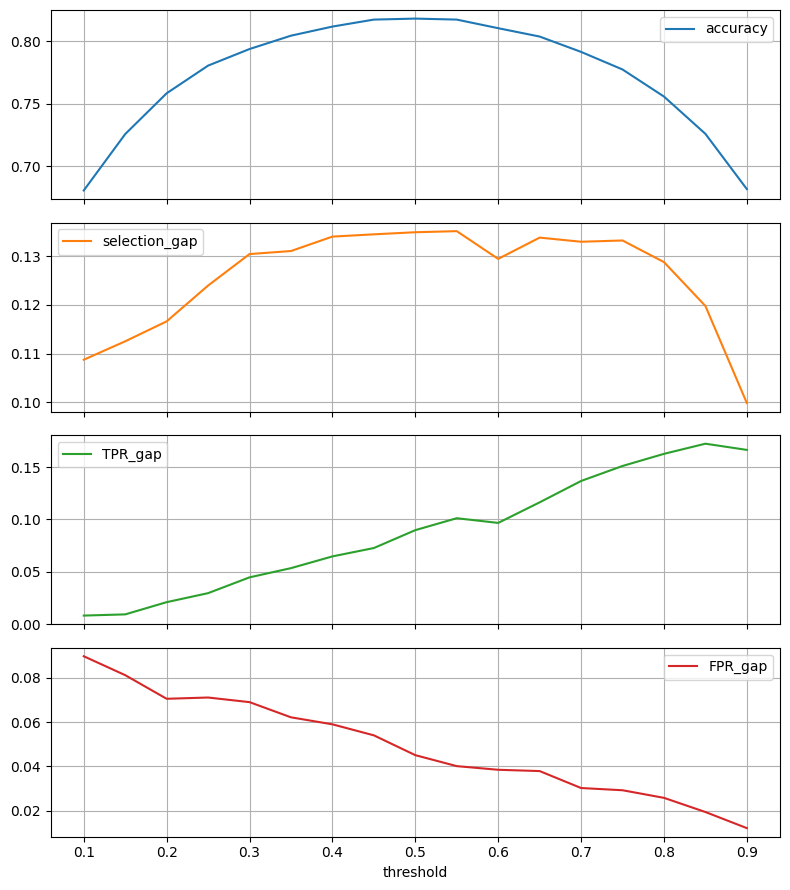

In [ ]:
rows = []
for threshold in np.linspace(.1, .9, 17):
    pred = (val_score >= threshold).astype(int)
    frame = MetricFrame(
        metrics={"selection": selection_rate, "TPR": recall_score, "FPR": false_positive_rate_metric},
        y_true=y_val, y_pred=pred, sensitive_features=A_val,
    )
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, pred),
        "selection_gap": frame.difference()["selection"],
        "TPR_gap": frame.difference()["TPR"],
        "FPR_gap": frame.difference()["FPR"],
    })
sweep = pd.DataFrame(rows)
display(sweep)
sweep.set_index("threshold").plot(subplots=True, figsize=(8,9), grid=True)
plt.tight_layout()

- The main takeaway from above is that the accuracy peaks where the selection gap is largest. Meaning we have a tradeoff between model performance and fairness

## 5. Sensitive-feature removal and intersectional audit

Complete both tasks. Report group-specific values and subgroup counts, not only gaps.

Removing sensitive-feature solve the problem? What are other short-comings you can think of?

In [ ]:
FEATURES_WITHOUT_A = [c for c in FEATURES if c not in ["SEX", "RAC1P"]]

model_without_a = make_model(X_train[FEATURES_WITHOUT_A])
model_without_a.fit(X_train[FEATURES_WITHOUT_A], y_train)
val_score_without_a = model_without_a.predict_proba(X_val[FEATURES_WITHOUT_A])[:, 1]
val_pred_without_a = (val_score_without_a >= .50).astype(int)

In [ ]:
mf_without_a = MetricFrame(
    metrics=metrics,
    y_true=y_val,
    y_pred=val_pred_without_a,
    sensitive_features=A_val,
)

print("Overall threshold metrics (model without A)")
display(pd.Series(mf_without_a.overall))
print("By group (model without A)")
display(mf_without_a.by_group)
print("Maximum minus minimum (model without A)")
display(pd.Series(mf_without_a.difference(method="between_groups")))
print("Minimum divided by maximum (model without A)")
display(pd.Series(mf_without_a.ratio(method="between_groups")))

Overall threshold metrics (model without A)


,0
n,10000.000000
accuracy,0.819500
balanced_accuracy,0.813544
selection_rate,0.410600
TPR,0.780268
FPR,0.153181
PPV,0.780078
NPV,0.846963
TNR,0.846819


By group (model without A)


,n,accuracy,balanced_accuracy,selection_rate,TPR,FPR,PPV,NPV,TNR
SEX,,,,,,,,,
Female,4720.0,0.819068,0.806529,0.365890,0.765027,0.151969,0.729589,0.870698,0.848031
Male,5280.0,0.819886,0.817990,0.450568,0.790480,0.154500,0.816730,0.822475,0.845500


Maximum minus minimum (model without A)


,0
n,560.000000
accuracy,0.000819
balanced_accuracy,0.011461
selection_rate,0.084678
TPR,0.025453
FPR,0.002532
PPV,0.087141
NPV,0.048223
TNR,0.002532


Minimum divided by maximum (model without A)


,0
n,0.893939
accuracy,0.999002
balanced_accuracy,0.985989
selection_rate,0.812063
TPR,0.967801
FPR,0.983614
PPV,0.893305
NPV,0.944615
TNR,0.997015


- The above is a similar setup as previously only difference is race and sex are omitted from the training features

- THe point is to compare the reuslts and see if any of the other features potentially acts as proxies for sex or race. But we will ignore race for now and focus on sex

**Independence**:

*With sensitive attributes(sex and race)*:
- Men have a higher selection rate (\~47 %) compared to women (\~34%)

- This is a disrepancy of $\frac{0.34}{0.47}=0.72$ which is below 80 % indicating independence is violated with regards to sex

*Without sensitive attributes(sex and race)*:
- Selection rate: Men ~45% and Women ~37%, ratio ~81%
- Disrepancy is below 20 %


**Separation**:

*With sensitive attributes*:
- When analyzing equalized odds(TPR and FPR), the largest disrepancy can be found in FPR of 26%. Men have a higher FPR(\~18%) compared to women (\~13%)

- This means men are more likely to be falsely assumed to be earning above 50 K compared to women. In other words the model overestimates men that make above 50 K.

*Without sensitive attributes*:
- TPR: Men 79 % and women 77 %
- FPR: men 15 % and women 15 %
- Largest disrepancy is ~3% well below 20 %



**Sufficiency**:
- Looking at the disrepancy for men and women in PPV and NPV both of these are above ~90 % and does not motivate further attention
- SImilar in model without sensitive attributes



- When comparing the two models with regards to indepence we now see without the sensitive attributes the independence is no violateD, same with separation

- The disrepancy is not compeltely eliminated but is just means that the features do not act as necessarily strong proxies for the sensitive attributes

Excluding SEX and RAC1P from training substantially reduced fairness gaps across independence (ratio 0.72→0.81) and separation (FPR gap 26%→3%), suggesting that for this dataset, sex/race carried a large amount of direct predictive weight not strongly duplicated by proxy features — a more encouraging result than the "unawareness rarely works" pattern often emphasized in the literature, though a small residual disparity remains and this result shouldn't be assumed to generalize to other datasets or attributes (e.g., the education/age relationship in Bank Marketing, which likely proxies far more strongly)



In [15]:
overall_probability_metrics_without_a = pd.Series({
    "ROC_AUC": roc_auc_score(y_val, val_score_without_a),
    "log_loss": log_loss(y_val, val_score_without_a)
})
display(overall_probability_metrics_without_a)

prob_rows_without_a = []
for g in A_val.unique():
    m = A_val.eq(g).to_numpy()
    prob_rows_without_a.append({
        "group": g, "n": m.sum(),
        "ROC_AUC": roc_auc_score(y_val[m], val_score_without_a[m]),
        "log_loss": log_loss(y_val[m], val_score_without_a[m])
    })
display(pd.DataFrame(prob_rows_without_a).set_index("group"))

,0
ROC_AUC,0.894791
log_loss,0.403851


,n,ROC_AUC,log_loss
group,,,
Female,4720,0.893247,0.394978
Male,5280,0.894653,0.411783


In [ ]:
# Optional SKIP, FOCUS ON SEX, NO ROOM ON POSTER

# TODO 2: create an intersectional sensitive feature such as SEX x RACE.
# Require a minimum group size before interpreting a result.
intersection = A_val.astype(str) + " | " + R_val.astype(str)
display(intersection.value_counts().head(15))

## Task 2: Perform fairness auditing on a marketing campaign dataset

Repeat the analysis on a new dataset - https://fairlearn.org/v0.13/api_reference/generated/fairlearn.datasets.fetch_bank_marketing.html

What do you learn about bias diagnostic? How are these metrics different?

## 📝 Project 1 Submission Guidelines

**Format:** Project 1 will be submitted as an **A0 Poster**.

**Week 1 Contribution:**
The findings and discussions generated from this Week 1 notebook should form the foundation of your project and cover approximately **1/3 of your final poster**.

When preparing your poster, ensure that this section includes:
* Clearly outline the context, goals, and intended real-world impact of the model.
* Explain what the different fairness metrics represent in the context of this specific use case (e.g., what does a disparity in False Positive Rate mean for the individuals actually affected?).
* Provide a short analysis of the bias present in the ACSIncome dataset and Bank Marketing dataset - from your exploratory data analysis and the fairness metric evaluations conducted in this notebook.

#**For the Poster**

- **The task**  is to create a binary classification model that can predict whether and Invidual's income exceeds a specific threshold

- **The Dataset**  used for training the model contains features such as age, education, occupation, maritial status hours worked. The sensitive attributes of investigation are sex and race.

- **The outcome** is predicting the specific feature "income_observed" which is a binary label for whether a persons income exceeds 50 k or not. Initially this label is treated as ground truth but later learned in part (3) that it is an imperfect proxy and a new reference label is introduced as ground truth.



- **Independence**:Regardless of the person's sex they should be equally flagged to earn >50k. Selection rate shows a disrepancy of 28 % when including the sensitive attributes and 19 % when excluding them meaning independence is not violated.

- **Separation**: TPR and FPR should be equal across sex regardless of whether a person earns >50k. The maximum equalized odds difference is found when comparing...

- **Sufficiency**: When the models predicts someone earns >50k that prediction is equally trustworthy regardless of sex.


- We have the tables we can compare
- We have ROCAUC and log loss results to comapre to TPR and FPR
- We have bank marketing dataset that can be used to look at the presence of proxies but we cant comapre sex


- one story is focus on what happens when we include/exclude sensitive attributes do other features acts as proxies ? what other features acts as proxies ? So for income dataset we see the other attributes do not act as strong proxies but with the bank marketing datset we might occupation do so heavily for education?

- Another story is simply the investigating fairness between men and women in the income dataset with regards to the mrtcsi: indepdence, separation, sufficiency, AUROC, log loss

-

## Tables

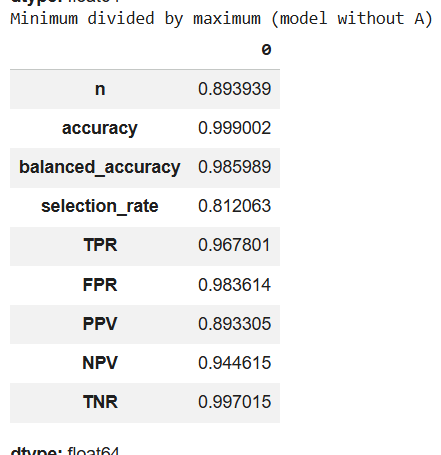

## Tables


**Table 1 — Fairness ratios, with vs. without sensitive attributes**

| Criterion | Metric | Ratio (with) | Ratio (without) |
|---|---|---|---|
| Independence | Selection rate | 0.72 | 0.81 |
| Separation | TPR | 0.89 | 0.97 |
| Separation | FPR | 0.75 | 0.98 |
| Sufficiency | PPV | 0.93 | 0.89 |
| Sufficiency | NPV | 0.98 | 0.94 |

**Table 2a — ROC AUC, with vs. without sensitive attributes**

| Group | With | Without |
|---|---|---|
| Overall | 0.90 | 0.90 |
| Female | 0.89 | 0.89 |
| Male | 0.90 | 0.90 |

**Table 2b — Log loss, with vs. without sensitive attributes**

| Group | With | Without |
|---|---|---|
| Overall | 0.40 | 0.40 |
| Female | 0.39 | 0.40 |
| Male | 0.41 | 0.41 |

# **General Questions**

## How do we check independence?

- Just look at the selection rate for the different groups
- If the disrepancy is more than 20 % between the worst and the best performin ggroup, this should higlighted and potentially affirmed as a violation.
- Disrepancy is checked by: $\frac{min(selection\_rate)}{max(selection\_rate)}=>0.8$



## How do we check separation(equalized odds)?

- Same approach as in independece only here we check TPR and FPR
- We compare TPR across groups and we compare FPR across groups, and then we use the largest disrepancy in either FPR or TPR to confirm whether there is a violation or not

## How do we check sufficiency?

- Same approach as independence and separation
- Difference is we check PPV and NPV instead across groups

## How large should the difference be before we react and say there is a violation?

- The formula for the fairness metrics uses equal signs so any difference would be a violation
- In practice the difference should be more than 20 % disrepancy before we react

## How to combine AUCROC, TPR/FPR, log_loss in an interpretation ?

- TPR and FPR is the models performance set at a specific threshold ¨

- AUCROC tells the models performance in general regardsless of the threshold. It checks all thresholds

- Log loss tells us how much we can trust the probabilities output from the model

- If AUC differs a lot by group the model is bad at distinguishing classes across groups

- If AUC is similar but TPR/FPR differs alot, the models raw ability is fine but the chosen threshold ( where TPR and FPR have been measured) are not optimal

- If TPR/FPR are similar but log loss differs, the model makes fine predictions but the actual probabilities themselves cannot be trusted necessarily. So 0.6 and 0.8 are both above 0.5 and will be thresholded to 1 but if the model gives a 0.6 probability and does probabilities are not accurate 0.6 of the time the log loss increases. This is also part of calibration

- Difference between AUC and log loss is AUC does not measure accuracy but ranking so the ability of the model to distiguish between classes. wheere log loss direcly evaluates the models ability to give the right probability
